In [10]:
!pip install matplotlib pandas requests seaborn tqdm yfinance

In [2]:
from functools import lru_cache
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns
sns.set_style("darkgrid")

# 1. Build Long DXY History

In [3]:
START_DATE = pd.Timestamp("1971-02-01")
DXY_CHANGEOVER = pd.Timestamp("1999-01-01")
END_DATE = pd.Timestamp("2026-03-13")

MODERN_SPEC = pd.DataFrame([
    {"ccy": "EUR", "pair": "EURUSD", "fred": "DEXUSEU", "weight": 57.6, "sign": -1},
    {"ccy": "JPY", "pair": "USDJPY", "fred": "DEXJPUS", "weight": 13.6, "sign": 1},
    {"ccy": "GBP", "pair": "GBPUSD", "fred": "DEXUSUK", "weight": 11.9, "sign": -1},
    {"ccy": "CAD", "pair": "USDCAD", "fred": "DEXCAUS", "weight": 9.1, "sign": 1},
    {"ccy": "SEK", "pair": "USDSEK", "fred": "DEXSDUS", "weight": 4.2, "sign": 1},
    {"ccy": "CHF", "pair": "USDCHF", "fred": "DEXSZUS", "weight": 3.6, "sign": 1}
]).set_index("ccy")

HISTORIC_SPEC = pd.DataFrame([
    {"ccy": "DEM", "pair": "USDDEM", "fred": "EXGEUS", "weight": 20.8, "sign": 1},
    {"ccy": "FRF", "pair": "USDFRF", "fred": "EXFRUS", "weight": 13.1, "sign": 1},
    {"ccy": "ITL", "pair": "USDILT", "fred": "EXITUS", "weight": 9.0, "sign": 1},
    {"ccy": "NLG", "pair": "USDNLG", "fred": "EXNEUS", "weight": 8.3, "sign": 1},
    {"ccy": "BEF", "pair": "USDBEF", "fred": "EXBEUS", "weight": 6.4, "sign": 1},
]).set_index("ccy")


MODERN_MULTIPLIER = 50.14348112

GUESSED_HISTORIC_MULTIPLIER = 12.5


assert MODERN_SPEC.weight.sum() == 100
assert MODERN_SPEC.loc["EUR"].weight == HISTORIC_SPEC.weight.sum()

In [5]:
@lru_cache(maxsize=1024)
def fetch_fred(series: str, name: str, to_month_end: bool) -> pd.DataFrame:
    """
    Fetch some data from FRED as a [time] x [name] dataframe

    Parameters
    ----------
    series: str
        The FRED series identifier
    name: str
        What you want to call the column
    to_month_end: bool
        Whether to shift the date from the first of the month to the end of the month
    """
    uri = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"
    df = pd.read_csv(uri, parse_dates=["observation_date"])

    df = df.rename(columns={series: name})

    if to_month_end:
        df["observation_date"] += pd.offsets.BMonthEnd(0)

    df = df.set_index("observation_date")
    
    return df


def get_modern_data(silence: bool) -> pd.DataFrame:
    """
    Get the modern constituents as [time] x [pair] dataframe @ daily frequency

    Parameters
    ----------
    silence: bool
        Do not show progress through downloads
    """
    data = []
    for ccy, row in tqdm(MODERN_SPEC.iterrows(), total=MODERN_SPEC.shape[0], disable=silence, desc="Fetching modern"):
        df = fetch_fred(series=row.fred, name=ccy, to_month_end=False).copy()  # protect LRU
        df = df.loc[df.index >= START_DATE]
        df = df.loc[df.index <= END_DATE]
        data.append(df)
    return pd.concat(data, axis=1, sort=True)


def get_historic_data(silence: bool) -> pd.DataFrame:
    """
    Get the historical constituents as [time] x [pair] dataframe @ monthly frequency

    Parameters
    ----------
    silence: bool
        Do not show progress through downloads
    """
    data = []
    for ccy, row in tqdm(HISTORIC_SPEC.iterrows(), total=HISTORIC_SPEC.shape[0], disable=silence, desc="Fetching historic"):
        df = fetch_fred(series=row.fred, name=ccy, to_month_end=True).copy()  # protect LRU
        df = df.loc[df.index >= START_DATE]
        df = df.loc[df.index <= END_DATE]
        data.append(df)
    return pd.concat(data, axis=1, sort=True)


def get_historic_constituents(silence: bool) -> pd.DataFrame:
    """
    Get the historic DXY constituents as a monthly [time] x [ccy] dataframe

    Parameters
    ----------
    silence: bool
        Do not show progress through downloads
    """
    his_data = get_historic_data(silence)

    mod_data = get_modern_data(silence).drop(columns=["EUR"])
    mod_data = mod_data.resample("BME").last()
    
    his_data = his_data.loc[(his_data.index >= START_DATE) & (his_data.index <= DXY_CHANGEOVER)]
    mod_data = mod_data.loc[(mod_data.index >= START_DATE) & (mod_data.index <= DXY_CHANGEOVER)]

    assert (his_data.index == mod_data.index).all()

    return pd.concat([his_data, mod_data], axis=1)


def get_modern_constituents(silence: bool) -> pd.DataFrame:
    """
    Get modern DXY constituents as a monthly [time] x [ccy] dataframe

    Parameters
    ----------
    silence: bool
        Do not show progress through downloads
    """
    mod_data = get_modern_data(silence)
    mod_data = mod_data.loc[(mod_data.index > DXY_CHANGEOVER) & (mod_data.index <= END_DATE)]
    return mod_data


def get_synthetic_dxy() -> pd.Series:
    """
    Get DXY over a long period of time by stitching the two versions
    """
    his = get_historic_constituents(silence=False)
    mod = get_modern_constituents(silence=True)

    def compute_historic(row: pd.Series) -> float:
        total = GUESSED_HISTORIC_MULTIPLIER
        for ccy, spec in HISTORIC_SPEC.iterrows():
            exponent = 0.01 * spec.weight * spec.sign
            total *= (row[ccy] ** exponent)
        for ccy, spec in MODERN_SPEC.loc[MODERN_SPEC.index != "EUR"].iterrows():
            exponent = 0.01 * spec.weight * spec.sign
            total *= (row[ccy] ** exponent)
        return total

    def compute_modern(row: pd.Series) -> float:
        total = MODERN_MULTIPLIER
        total_weight = 0.0
        for ccy, spec in MODERN_SPEC.iterrows():
            exponent = 0.01 * spec.weight * spec.sign
            total *= (row[ccy] ** exponent)
        return total
    
    his["DXY"] = his.apply(compute_historic, axis=1)
    mod["DXY"] = mod.apply(compute_modern, axis=1)

    assert his.index.max() < mod.index.min()
    
    result = pd.concat([his.DXY, mod.DXY], axis=0)
    result.index.name = None

    return result
    

In [6]:
dxy = get_synthetic_dxy()

Fetching historic:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching modern:   0%|          | 0/6 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Synthetic DXY')

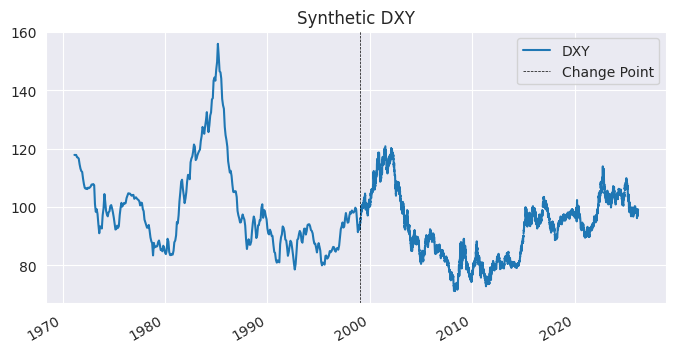

In [7]:
fig, ax = plt.subplots(figsize=(8,4))


pre = dxy[dxy.index <= DXY_CHANGEOVER].iloc[-1]
post = dxy[dxy.index > DXY_CHANGEOVER].iloc[0]



dxy.plot(ax=ax)
ax.axvline(DXY_CHANGEOVER, linestyle='--', color='k', lw=0.5, label="Change Point")
ax.legend(loc='upper right')
ax.set_title("Synthetic DXY")